# Modelling stock prices using random walks

I first created a 1d random walk in the way that felt most intuitive to me, using a for loop. After some research, I realised the numpy function I used does not require the loop and has a built in paramter to create the array.

In [9]:
#importing relevant modules
import numpy as np
import matplotlib.pyplot as plt


def randwalk_org(steps):
    #initialising price lsit
    values = []


    for n in range(steps):
        p = int(np.random.choice([-1,1])) #randomly choose between +1 or 01
        values.append(p) #adding each  to list
    return values
    

In [10]:
randwalk_org(5)

[-1, 1, 1, -1, 1]

In [43]:
def randwalk(steps):
    return np.random.choice([-1,1],steps) #random.choice function can create an array itself without loop
    

In [42]:
randwalk(5)

array([-1, -1,  1, -1, -1])

The next step was to adapt this random walk to be helpful for stock price movements. Stock price changes are proportional to the price they are at meaning I had to change the additive +1 or -1 to multipliers. I intiially continued to use only +1% or -1% then extented this to be a normal distrbution instead.

In [60]:
def price_predict(org_price,steps):
    multipliers = randwalk(steps)/100 + np.repeat(1,steps) #creating array of random multipleirs

    for m in multipliers:
        org_price = org_price*m
    return org_price

price_predict(5,3)

np.float64(5.049495)

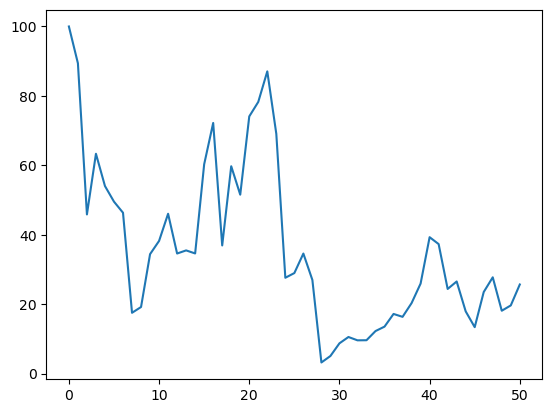

In [114]:
def price_predict_new(org_price,steps,volatility):
    """
    Input:
    Org_price - The original price of the stock in pounds
    Steps - The number of days to predict over
    Volatility - The standard deviation of the normal distrubtion, reflects how likely
    big changes in stock can be.

    Output:
    Prices - List of prices across the next "steps" number of days
    """
    
    multipliers = np.random.normal(0,volatility,steps)  + np.repeat(1,steps)

    prices = [org_price]
    for m in multipliers:
        org_price = org_price*m
        prices.append(org_price)
    
    return prices

prices = price_predict_new(100,50,0.4)

plt.figure()
plt.plot(prices)
    
    